In [1]:
import math
from scipy.integrate import odeint
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import sys
from mpl_toolkits.mplot3d import Axes3D
from scipy.integrate import solve_ivp 

# Double/Triple Product

In [2]:
def double_prod(i: int, j: int):
    ''' Calculate double product for H_i, H_j

    Parameters
    ----------
    i: non-negative integer
    j: non-negative integer

    Returns
    -------
    i! if i = j
    0 if i != j
    '''
    if i != j:
        return 0
    else:
        return math.factorial(i)

In [3]:
def triple_prod(i: int, j: int, k: int):
    ''' Calculate triple product for H_i, H_j, H_k
    
    Parameters
    ----------
    i: non-negative integer
    j: non-negative integer
    k: non-negative integer

    Returns
    -------
    0 if (i+j+k)% 2 != 0 or s<max(i,j,k)
    i!j!k!/((s-i)!(s-j)!(s-k)!)
    '''
    s = (i+j+k)//2
    if (i+j+k)% 2 != 0 or s<max(i,j,k):
        return 0
    else:
        return (math.factorial(i) * math.factorial(j) * math.factorial(k)) / (
            math.factorial(s-i) *
            math.factorial(s-j) *
            math.factorial(s-k))

## Get derivatives

In [4]:
# Function xderiv_forward(y, delta_x)
    # y: Nx1 vector, including its boundary points
    # return a numerical approximation of dy/dx evaluated at each entry of y
def xderiv_forward(y, delta_x):
    N = len(y)
    dydx = np.zeros(N) #Initilize output vector
    
    # Forward difference for estimated values of y up to N-2 values of x
    for i in range (N-1):
        dydx[i] = (y[i+1] - y[i])/delta_x
    # Backward difference for estimated value of y at x_{N-1}
    dydx[N-1] = (y[N-1] - y[N-2])/delta_x
    return dydx

In [5]:
# Function xderiv_central(y, delta_x)
    # y: Nx1 vector, including its boundary points
    # return a numerical approximation of dy/dx evaluated at each entry of y
def xderiv_central(y, delta_x):
    N = len(y)
    dydx = np.zeros(N) #Initilize output vector
    
    # Forward difference at x_0
    dydx[0] = (y[1] - y[0]) / delta_x
    
    # Central difference for points x_1...x_{N-2}
    for i in range(1, N - 1):
        dydx[i] = (y[i + 1] - y[i - 1]) / (2 * delta_x)
        
    # Backward difference at last point x_{N-1}
    dydx[N - 1] = (y[N - 1] - y[N - 2]) / delta_x
    return dydx

In [6]:
# Function getallxderiv(u, delta_x)
    # Input: u: 2xN matrix
    # return du/dx (2xN matrix)
def getallxderiv(u, delta_x):
    u = np.asarray(u)
    num_row, N = u.shape # Get the dimensions of u
    dudx = np.zeros_like(u) # Initialize (M+1)xN matrix du/dx

    # Get derivatives for each row
    for i in range(num_row):
        dudx[i,:] = xderiv_central(u[i,:], delta_x) 
    return dudx

## Get initial condition function

In [7]:
def getinitcond(x, M, ic_type = 'cond_1'):
    ''' Function getinitcond: returns initial condition

    Parameters
    ----------
    x: array
        An array of length N. This can be understood as the gridpoints
    M: non-negative integer
        Truncation limit. For now, we are limiting our function to M = 1 and M = 2
    ic_type: string
        Type of initial condition we are working with. For now, there are 2 modes.
        cond_1: u(x,t=0,ξ) = ξ np.sin(x)
        cond_2: u(x,t=0,ξ) = ξ^2 np.sin(x)

    Returns
    -------
    u_init: (M+1)x N matrix
        Initial condition matrix
    '''
    N = len(x)
    u_init = np.zeros((M+1,N)) # Initialize initial condition matrix
    if ic_type == 'cond_1':
        if M >= 1:
            u_init[1,:] = np.sin(x)
    elif ic_type == 'cond_2':
        if M >= 1:
            u_init[0,:] = np.sin(x)
        if M >= 2:
            u_init[2,:] = np.sin(x)
    return u_init

# Inviscid Burgers Equation

In [8]:
# For k = 0
def BurgersKEqualsZeroEqn(u, delta_x):
    ''' Calculate the equation for k = 0 in a system M

    Parameters
    ----------
    u: (M+1) x N matrix. 
        The matrix at a given time t. Here u[k,:] = u_k, for k in {0,...,M}
    delta_x: float
        Step size in the x-axis. Can also be understood as the spacing between each grid point

    Returns
    -------
    EqnKEqualsZero: array of length N
        One-dimensional array of length N. Representing u_0 
    '''
    num_vars = u.shape[0]
    dudx = getallxderiv(u, delta_x) # Get derivatives of all entries in matrix u using getallxderiv function

    # Compute equation
    if num_vars == 1:
        EqnKEqualsZero = -u[0,:] * dudx[0,:]
    # For M = 1 (number of variables is 2: u0 and u1)
    if num_vars == 2:
        EqnKEqualsZero = -u[0,:] * dudx[0,:] - u[1,:] * dudx[1,:]
    # For M = 2(u0, u1, u2)
    elif num_vars == 3:
        EqnKEqualsZero = -u[0,:] * dudx[0,:] - u[1,:] * dudx[1,:] - u[2,:] * dudx[2,:]

    return EqnKEqualsZero

In [9]:
# For k = 1
def BurgersKEqualsOneEqn(u, delta_x):
    ''' Calculate the equation for k = 0 in a M-system 
    
    Parameters
    ----------
    u: (M+1) x N matrix. 
        The matrix at a given time t. Here u[k,:] = u_k, for k in {0,...,M}
    delta_x: float
        Step size in the x-axis. Can also be understood as the spacing between each grid point

    Returns
    -------
    EqnKEqualsOne: array of length N
        One-dimensional array of length N. Representing u_1 
    '''
    # get the number of rows in the matrix
    num_vars = u.shape[0]
    dudx = getallxderiv(u, delta_x)
    
    # Compute equation
    # For M = 1
    if num_vars == 2:
        EqnKEqualsOne = -u[0,:] * dudx[1,:] - u[1,:] * dudx[0,:]
        
    # For M = 2
    elif num_vars == 3:
        EqnKEqualsOne = -u[1,:] * dudx[0,:] - (u[0,:] + 2*u[2,:]) * dudx[1,:] - 2*u[1,:] * dudx[2,:]
        
    return EqnKEqualsOne

In [10]:
# For k = 2
def BurgersKEqualsTwoEqn(u, delta_x):
    ''' Calculate the equation for k = 0 in a M-system 
    
    Parameters
    ----------
    u: (M+1) x N matrix. 
        The matrix at a given time t. Here u[k,:] = u_k, for k in {0,...,M}
    delta_x: float
        Step size in the x-axis. Can also be understood as the spacing between each grid point

    Returns
    -------
    EqnKEqualsTwo: array of length N
        One-dimensional array of length N. Representing u_2 
    '''
    num_vars = u.shape[0]
    dudx = getallxderiv(u, delta_x)
    
    # Compute equation for M=2, k=2
    EqnKEqualsTwo = -u[2,:] * dudx[0,:] - u[1,:] * dudx[1,:] - (u[0,:] + 4*u[2,:]) * dudx[2,:]
    return EqnKEqualsTwo

In [11]:
# General function
def GeneralBurgRHS(u, t, delta_x, M, N, ):
    ''' Calculate the solution matrix u in a M-system 
    
    Parameters
    ----------
    u: (M+1) x N matrix. 
        The solution matrix at a given time t. Here u[k,:] = u_k, for k in {0,...,M}
    t: vector
        Time vector
    delta_x: float
        Step size in the x-axis. Can also be understood as the spacing between each grid point
    M: non-negative integer
        Truncation limit. For now, the function is limited to M = 1 and M = 2
    N: non-negative integer
        Number of grid points (x-axis) in which we evaluate the solution
        
    Returns
    -------
    EqnM: array of length (M+1)*N
        One-dimensional (flattened) array of length (M+1)*N. We flatten it to put into ODE solver.
    '''
    # Reshape solution u to (M+1) x N matrix
    u = u.reshape(M+1, N)

    # For M = 0
    if M == 0:
        EqnKEqualsZero = BurgersKEqualsZeroEqn(u, delta_x)
        EqnM = EqnKEqualsZero.flatten()
        
    # For M = 1
    elif M == 1:
        EqnKEqualsZero = BurgersKEqualsZeroEqn(u, delta_x)
        EqnKEqualsOne = BurgersKEqualsOneEqn(u, delta_x)
        # Put into a (M+1) x N matrix
        EqnMEqualsOne = np.array([EqnKEqualsZero, EqnKEqualsOne])
        # Flatten for ODE solver
        EqnM = EqnMEqualsOne.flatten()

    # For M = 2
    elif M == 2:
        EqnKEqualsZero = BurgersKEqualsZeroEqn(u, delta_x)
        EqnKEqualsOne = BurgersKEqualsOneEqn(u, delta_x)
        EqnKEqualsTwo = BurgersKEqualsTwoEqn(u, delta_x)
        # Put into a (M+1) x N matrix
        EqnMEqualsTwo = np.array([EqnKEqualsZero, EqnKEqualsOne, EqnKEqualsTwo])
        EqnM = EqnMEqualsTwo.flatten()
    return EqnM

In [12]:
# General function that overrides result from previous system
def GeneralBurgHierachy(u, t, delta_x, M, N, u_from_M0 = None, u_from_M1 = None):
    ''' Do the same thing as the GeneralBurgRHS function but instead overides the solution from system M = 1 when M = 2

    Parameters
    ----------
    u: (M+1) x N matrix. 
        The matrix at a given time t. Here u[k,:] = u_k, for k in {0,...,M}
    t: vector
        Time vector
    delta_x: float
        Step size in the x-axis. Can also be understood as the spacing between each grid point
    M: non-negative integer
        Truncation limit. For now, the function is limited to M = 1 and M = 2
    N: non-negative integer
        Number of grid points (x-axis) in which we evaluate the solution
    u_from_M1: None or a tuple if solution from system M = 1 exists
        A 2-tuple containing u_0 and u_1 solving from BurgersKEqualsZeroEqn and BurgersKEqualsOneEqn for case M = 1

     Returns
    -------
    EqnM: array of length (M+1)*N
        One-dimensional (flattened) array of length (M+1)*N. We flatten it to put into ODE solver.
    '''
    u = u.reshape(M+1, N)
    # Case: M = 0
    if M == 0:
        EqnKEqualsZero = BurgersKEqualsZeroEqn(u, delta_x)
        EqnM = EqnKEqualsZero.flatten()

    # Case: M = 1
    elif M == 1:
        # If we have solutions from solving system M = 0, then proceed to use that here
        if u_from_M0 is not None:
            u0_M0 = u_from_M0[0]
            # Change matrix u accordingly to input in EqnKEqualsOne
            u[0,:] = u0_M0
            # Run EqnKEqualsOne only
            EqnKEqualsZero = np.zeros(N)
            EqnKEqualsOne = BurgersKEqualsOneEqn(u, delta_x)

        # Otherwise, solve normally
        else:
            EqnKEqualsZero = BurgersKEqualsZeroEqn(u, delta_x)
            EqnKEqualsOne = BurgersKEqualsOneEqn(u, delta_x)

        # Put into a (M+1) x N matrix
        EqnMEqualsOne = np.array([EqnKEqualsZero, EqnKEqualsOne])
        # Flatten for ODE solver
        EqnM = EqnMEqualsOne.flatten()

    # Case: M = 2
    elif M == 2:
        # If we have solutions from solving system M = 1, then proceed by using u_0 and u_1 from M = 1 system eqns
        if u_from_M1 is not None:
            u0_M1 = u_from_M1[0]
            u1_M1 = u_from_M1[1]
            # Change matrix u accordingly to input in EqnKEqualsTwo
            u[0,:] = u0_M1
            u[1,:] = u1_M1
            # Run EqnKEqualsTwo only
            EqnKEqualsZero = np.zeros(N)
            EqnKEqualsOne = np.zeros(N)
            EqnKEqualsTwo = BurgersKEqualsTwoEqn(u, delta_x)
        else:
            # Solve all three equations normally
            EqnKEqualsZero = BurgersKEqualsZeroEqn(u, delta_x)
            EqnKEqualsOne = BurgersKEqualsOneEqn(u, delta_x)
            EqnKEqualsTwo = BurgersKEqualsTwoEqn(u, delta_x)
            # Put into a (M+1) x N matrix
        EqnMEqualsTwo = np.array([EqnKEqualsZero, EqnKEqualsOne, EqnKEqualsTwo])
        EqnM = EqnMEqualsTwo.flatten()
        
    return EqnM

# TEST

In [13]:
# Test for Burgers RHS overwritting from M = 0 solutions for initial cond \xi sin(x)
N = 100
x = np.linspace(0, 2*np.pi, N)
delta_x = x[1] - x[0]
t = np.linspace(0, 0.2, 5)

#Solve M = 0 system normally
M0 = 0
u_init_M0 = getinitcond(x, M0, ic_type='cond_1') 
u_init_flat_M0 = u_init_M0.flatten()
M0_result = odeint(GeneralBurgHierachy, u_init_flat_M0, t, args=(delta_x, M0, N, None, None))


# Approximate M = 1 system by carrying over u_0 from M = 0 system
M1 = 1
u_init_flat_M1 = getinitcond(x, M1, ic_type='cond_1').flatten()  

for i in range(len(t)-1):
    u0_from_M0 = M0_result[i, 0:N]       
    u_from_M0 = (u0_from_M0)
    # Solve
    M1_result_inherited = odeint(GeneralBurgHierachy, u_init_flat_M1, t, 
                 args=(delta_x, M1, N, u_from_M0, None))

# Approximate M = 2 system by carrying over u_0 and u_1 from M = 1 system
M2 = 2
u_init_flat_M2 = getinitcond(x, M2, ic_type='cond_1').flatten()  

for i in range(len(t)-1):
    u0_from_M1 = M1_result_inherited[i, 0:N]      
    u1_from_M1 = M1_result_inherited[i, N:2*N]   
    
    u_from_M1 = (u0_from_M1, u1_from_M1)
    
    # Solve
    M2_result_inherited = odeint(GeneralBurgHierachy, u_init_flat_M2, t, 
                 args=(delta_x, M2, N, u_from_M0, u_from_M1))

In [14]:
# Solved normally
M1_result_normal = odeint(GeneralBurgRHS, u_init_flat_M1, t, args = (delta_x,M1,N))
M2_result_normal = odeint(GeneralBurgRHS, u_init_flat_M2, t, args = (delta_x,M2,N))

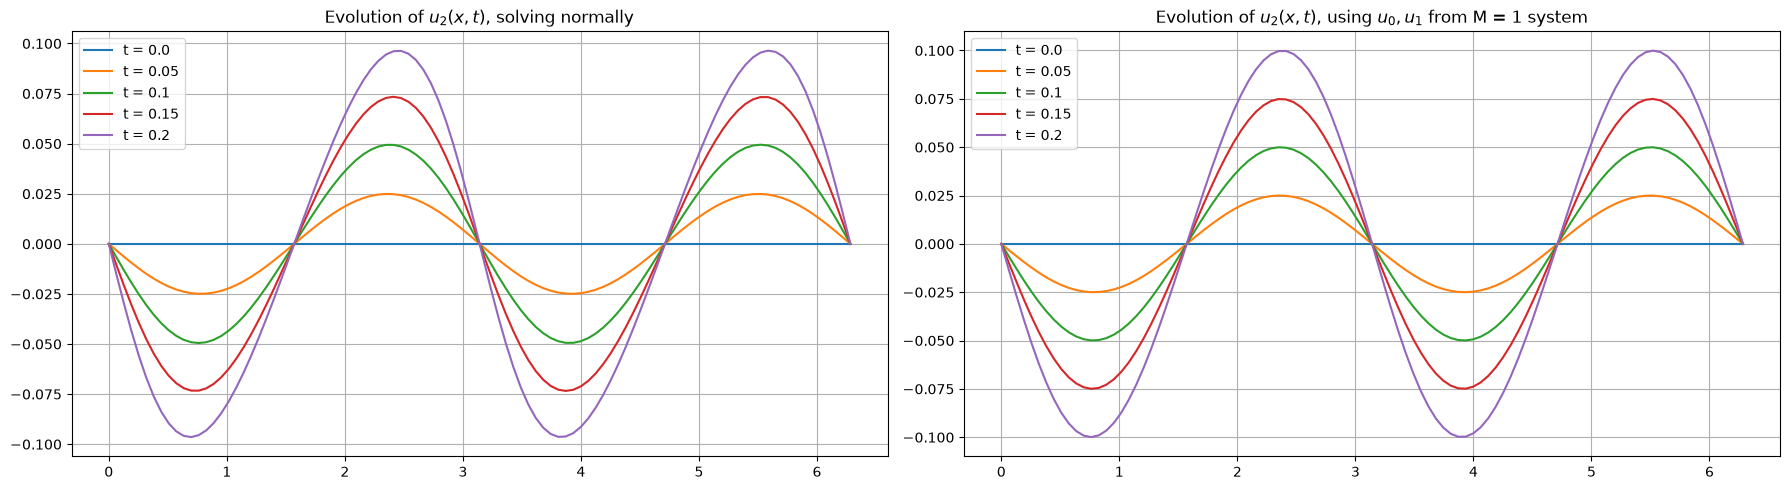

In [15]:
# Compare evolution of u2 for solving M = 2 normally and the one using results from M = 1
plt.figure(figsize=(18, 5))
for i in range(len(t)):
    time_val = t[i]

    plt.subplot(1, 2, 1)
    u2att = M2_result_normal[i, 2*N:3*N]
    plt.plot(x, u2att, label=f"t = {round(time_val, 2)}")
    plt.title("Evolution of $u_2(x,t)$, solving normally")
    plt.grid(True)

plt.subplot(1, 2, 1)
plt.legend()

for i in range(len(t)):
    time_val = t[i]

    plt.subplot(1,2,2)
    u2att = M2_result_inherited[i, 2*N: 3*N]
    plt.plot(x, u2att, label=f"t = {round(time_val, 2)}")
    plt.title("Evolution of $u_2(x,t)$, using $u_0, u_1$ from M = 1 system")
    plt.grid(True)

plt.subplot(1,2,2)
plt.legend()

plt.tight_layout()
plt.show()

## Test for initial condition $u(x,t=0, \xi) = \xi \sin (x)$

In [16]:
# Parameters and running odeint for initial condition u(x,0, \xi) = \xi sin(x)
M= 2
N = 100
x = np.linspace(0, 2*np.pi, N)
delta_x = x[1] - x[0]
#t = np.linspace(0,0.95,95)
u_init1 = getinitcond(x, M, ic_type='cond_1')
u_init1_flat = u_init1.flatten()  # Flatten to 1D array

result_cond1 = odeint(GeneralBurgRHS, u_init1_flat, t, args = (delta_x,M,N))

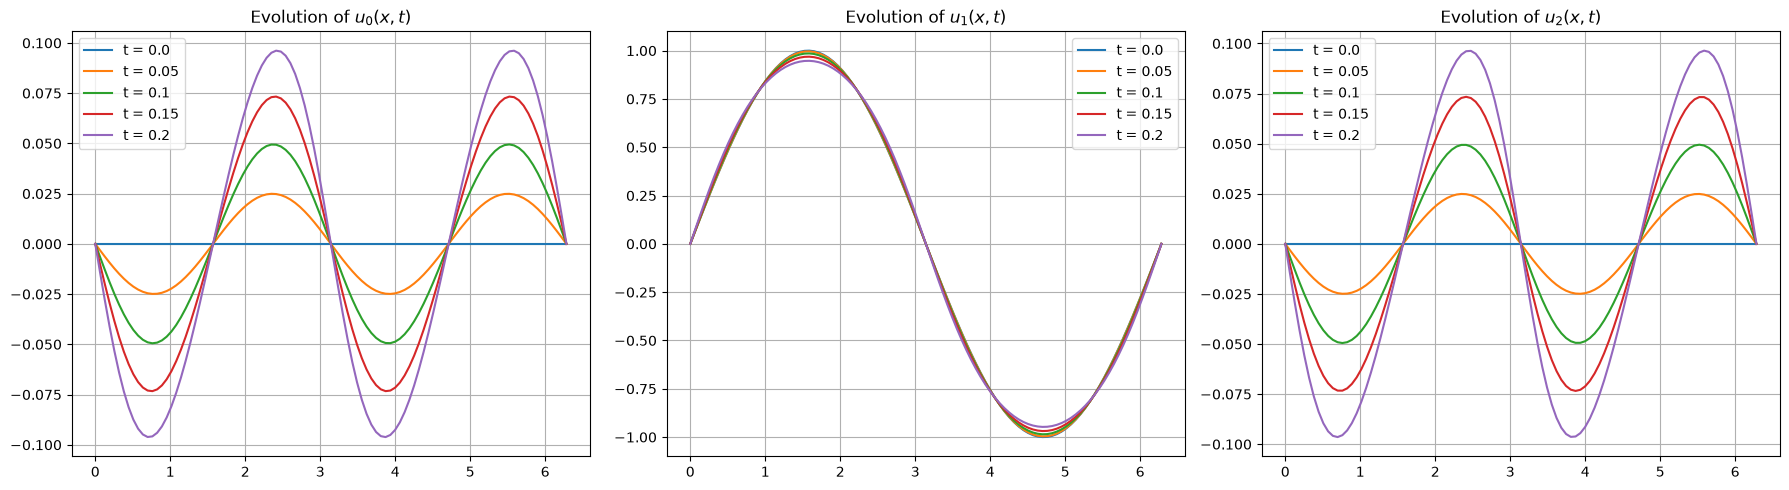

In [17]:
plt.figure(figsize=(18, 5))

for i in range(len(t)):
    time_val = t[i]
   
    plt.subplot(1, 3, 1)
    u0att = result_cond1[i, 0:N]
    plt.plot(x, u0att, label=f"t = {round(time_val, 2)}")
    plt.title("Evolution of $u_0(x,t)$")
    plt.grid(True)

plt.subplot(1, 3, 1)
plt.legend()

for i in range(len(t)):
    time_val = t[i]

    plt.subplot(1, 3, 2)
    u1att = result_cond1[i, N:2*N]
    plt.plot(x, u1att, label=f"t = {round(time_val, 2)}")
    plt.title("Evolution of $u_1(x,t)$")
    plt.grid(True)

plt.subplot(1, 3, 2)
plt.legend()

for i in range(len(t)):
    time_val = t[i]

    plt.subplot(1, 3, 3)
    u2att = result_cond1[i, 2*N:3*N]
    plt.plot(x, u2att, label=f"t = {round(time_val, 2)}")
    plt.title("Evolution of $u_2(x,t)$")
    plt.grid(True)

plt.subplot(1, 3, 3)
plt.legend()

plt.tight_layout()
plt.show()

## Test for Burgers RHS


## Test for initial condition $u(x,t=0, \xi) = \xi ^2 \sin(x)$

In [18]:
# # Test for Burgers RHS overwritting from M = 1 solutions
# N = 100
# x = np.linspace(0, 2*np.pi, N)
# delta_x = x[1] - x[0]
# t = np.linspace(0, 0.2, 5)

# #Solve M=1 system normally
# M1 = 1
# u_init_M1 = getinitcond(x, M1, ic_type='cond_2')  # 2xN matrix
# u_init_flat_M1 = u_init_M1.flatten()

# result_M1_Hierachy = odeint(GeneralBurgHierachy, u_init_flat_M1, t, args=(delta_x, M1, N, None))


# # Solve M=2 system using M=1 solution for u0 and u1
# M2 = 2
# u_init_M2 = getinitcond(x, M2, ic_type='cond_2').flatten()  

# for i in range(len(t)-1):
#     u0_from_M1 = result_M1_Hierachy[i, 0:N]      
#     u1_from_M1 = result_M1_Hierachy[i, N:2*N]   
    
#     u_from_M1 = (u0_from_M1, u1_from_M1)
    
#     # Solve
#     result_M2_Hierachy = odeint(GeneralBurgHierachy, u_init_M2, t, 
#                  args=(delta_x, M2, N, u_from_M1))
# # print(result_M1_Hierachy)
# # print(u0_from_M1)
# # print(u1_from_M1)

In [19]:
# # test for BurgersRHS solved normally
# M= 2
# N = 100
# x = np.linspace(0, 2*np.pi, N)
# delta_x = x[1] - x[0]
# t = np.linspace(0,0.2,5)
# u_init2 = getinitcond(x, M, ic_type='cond_2')
# u_init2_flat = u_init2.flatten()

# # 1. Create a 2xN matrix of test data
# # Row 1: sin(x) -> Derivative should be cos(x)
# # Row 2: x^2 -> Derivative should be 2x
# u_test = np.array([np.sin(x), x**2]) # **: exponential operator


# result_M2 = odeint(GeneralBurgRHS, u_init2_flat, t, args = (delta_x,M,N))
# type(result_M2)
# result_M2

In [20]:
# # Define values of u_0 and u_1 at different t
# u0_at_t0 = result_M2[0,0:N]
# u0_at_t1 = result_M2[1,0:N]
# u0_at_t2 = result_M2[2,0:N]
# u1_at_t0 = result_M2[0,N:2*N]
# u1_at_t1 = result_M2[1,N:2*N]
# u1_at_t2 = result_M2[2,N:2*N]
# u2_at_t0 = result_M2[0,2*N:3*N]
# u2_at_t1 = result_M2[1,2*N:3*N]
# u2_at_t2 = result_M2[2,2*N:3*N]
# # np.linalg.norm(u0_at_t1 - u2_at_t1)/np.linalg.norm(u0_at_t1)

### Plot for result solved normally

In [21]:
# plt.figure(figsize=(18, 5))

# for i in range(len(t)):
#     time_val = t[i]
   
#     plt.subplot(1, 3, 1)
#     u0att = result_M2[i, 0:N]
#     plt.plot(x, u0att, label=f"t = {round(time_val, 2)}")
#     plt.title("Evolution of $u_0(x,t)$")
#     plt.grid(True)

# plt.subplot(1, 3, 1)
# plt.legend()

# for i in range(len(t)):
#     time_val = t[i]

#     plt.subplot(1, 3, 2)
#     u1att = result_M2[i, N:2*N]
#     plt.plot(x, u1att, label=f"t = {round(time_val, 2)}")
#     plt.title("Evolution of $u_1(x,t)$")
#     plt.grid(True)

# plt.subplot(1, 3, 2)
# plt.legend()

# for i in range(len(t)):
#     time_val = t[i]

#     plt.subplot(1, 3, 3)
#     u2att = result_M2[i, 2*N:3*N]
#     plt.plot(x, u2att, label=f"t = {round(time_val, 2)}")
#     plt.title("Evolution of $u_2(x,t)$")
#     plt.grid(True)

# plt.subplot(1, 3, 3)
# plt.legend()

# plt.tight_layout()
# plt.show()

### Plot for result from GeneralBurgHierachy and GeneralBurgRHS

In [22]:
# # Compare evolution of u2 for solving M = 2 normally and the one using results from M = 1
# plt.figure(figsize=(18, 5))
# for i in range(len(t)):
#     time_val = t[i]

#     plt.subplot(1, 2, 1)
#     u2att = result_M2[i, 2*N:3*N]
#     plt.plot(x, u2att, label=f"t = {round(time_val, 2)}")
#     plt.title("Evolution of $u_2(x,t)$, solving normally")
#     plt.grid(True)

# plt.subplot(1, 2, 1)
# plt.legend()

# for i in range(len(t)):
#     time_val = t[i]

#     plt.subplot(1,2,2)
#     u2att = result_M2_Hierachy[i, 2*N: 3*N]
#     plt.plot(x, u2att, label=f"t = {round(time_val, 2)}")
#     plt.title("Evolution of $u_2(x,t)$, using $u_0, u_1$ from M = 1 system")
#     plt.grid(True)

# plt.subplot(1,2,2)
# plt.legend()

# plt.tight_layout()
# plt.show()

### Function solution plots

In [23]:
def eval_function(u0, u1, u2, xi):
    # Make u0, u1, u2 into columns (since time is fixed) to evaluate wrt xi values
    return u0[:, None] + u1[:, None] * xi + u2[:, None] * ((xi**2) - 1)
xi_vals = np.array([0, -1, 1, 0.05, -0.05, 0.1, -0.1, 0.01, -0.01, 0.7])
xi_sorted = np.sort(xi_vals)
sol_t_0 = eval_function(u0_at_t0, u1_at_t0, u2_at_t0, xi_sorted)
sol_t_1 = eval_function(u0_at_t1, u1_at_t1, u2_at_t1, xi_sorted)
sol_t_2 = eval_function(u0_at_t2, u1_at_t2, u2_at_t2, xi_sorted)

NameError: name 'u0_at_t0' is not defined

In [ ]:
plt.figure(figsize=(18, 5))

# For t = 0 
plt.subplot(1, 3, 1)
for i in range(len(xi_sorted)):
    plt.plot(x, sol_t_0[:, i], label=f'ξ = {xi_sorted[i]:.2f}')
plt.title("Evaluated Function Solution at t = 0")
plt.xlabel('x')
plt.ylabel(r'$u(x,t=0,\xi)$')
plt.grid(True, alpha=0.2)
plt.legend()

# For t = 0.05
plt.subplot(1, 3, 2)
for i in range(len(xi_sorted)):
    plt.plot(x, sol_t_1[:, i], label=f'ξ = {xi_sorted[i]:.2f}')
plt.title("Evaluated Function Solution at t = 0.05")
plt.xlabel('x')
plt.ylabel(r'$u(x,t=0.05,\xi)$')
plt.grid(True, alpha=0.2)
plt.legend()

# For t = 0.1
plt.subplot(1, 3, 3)
for i in range(len(xi_sorted)):
    plt.plot(x, sol_t_2[:, i], label=f'ξ = {xi_sorted[i]:.2f}')
plt.title("Evaluated Function Solution at t = 0.1")
plt.xlabel('x')
plt.ylabel(r'$u(x,t=0.1,\xi)$')
plt.grid(True, alpha=0.2)
plt.legend()

plt.tight_layout()
plt.show()

## 3D Plot

In [ ]:
# # u0atallt = result_M2[:, 0:N]
# # u1atallt = result_M2[:, N:2*N]
# # u2atallt = result_M2[:, 2*N:3*N]

# u0att = result_cond1[:, 0:N]
# u1att = result_cond1[:, N:2*N]
# u2att = result_cond1[:, 2*N:3*N]
# x_axis = np.linspace(0, 3, N)
# y_axis = t
# # result_M2.shape
# # result_M2

In [ ]:
# # For xi = -1
# # z_axis = u0atallt + u1atallt * (0.01) + u2atallt * ((0.01)**2 -1)
# z_axis = u0att + u1att * (0.0) + u2att * ((0.0)**2 -1)
# X,Y = np.meshgrid(x_axis, y_axis)
# print(z_axis.shape)
# print(x_axis.shape)
# print(y_axis.shape)
# fig = plt.figure()
# ax = plt.axes(projection='3d')
# ax.plot_surface(X, Y, z_axis, cmap='viridis',antialiased=True)
# ax.set_title(r'Solution $u(x,t, \xi)$ for $\xi = 0.01$')
# plt.show()

In [ ]:
# u0atallt_ = result_cond1[:, 0:N]
# u1atallt_ = result_cond1[:, N:2*N]
# u2atallt_ = result_cond1[:, 2*N:3*N]
# x_axis1 = np.linspace(0, 2*np.pi, N)
# y_axis1 = np.linspace(0,0.2,5)
# # For xi = -1
# z_axis = u0atallt_ + u1atallt_ * (-1) + u2atallt_ * ((-1)**2 -1)
# X,Y = np.meshgrid(x_axis, y_axis)
# print(z_axis.shape)
# print(x_axis.shape)
# print(y_axis.shape)
# fig = plt.figure()
# ax = plt.axes(projection='3d')
# ax.plot_surface(X, Y, z_axis, cmap='viridis',antialiased=True)
# ax.set_title(r'Solution $u(x,t, \xi)$ for $\xi = -1$')
# plt.show()

# SANITY CHECK!!!

## Test case

In [ ]:
N_test = 3
delta_x_test = np.pi

# Test case for M = 1
M1 = 1
# Test values for u_0 and u_1 at 3 time points x_0 = =, x_1 = np.pi, x_2 = 2*np.pi
u_test = np.array([
    [0.0, 1.0, 2.0],
    [1.0, 0.5, 0.0]
])

# Test case for M = 2
M2 = 2
# Test values for u_0, u_1, u_2 at x = [0, π, 2π]
u_test_M2 = np.array([
    [0.0, 1.0, 2.0],   # u_0
    [1.0, 0.5, 0.0],   # u_1
    [0.5, 0.3, 0.1]    # u_2
])

## M = 1: Compare results of computing Burgers RHS manually and by Python functions

In [ ]:
# For M = 1, k=0
u0 = u_test[0]
u1 = u_test[1]

# Compute derivatives
du0_dx_manual = xderiv_central(u0, delta_x_test)
du1_dx_manual = xderiv_central(u1, delta_x_test)

# For k = 0, RHS = u_0 \frac{\partial u_0}{\partial x} - u_1 \frac{\partial u_1}{\partial x}
nonlinear_0_manual = u0 * du0_dx_manual + u1 * du1_dx_manual
rhs_0_manual = -nonlinear_0_manual

print("Manual RHS for k=0:")
print(rhs_0_manual)

# Compute using Py functions
rhs_0_func = BurgersKEqualsZeroEqn(u_test, delta_x_test)
print("\nFunction RHS for k=0:")
print(rhs_0_func)

print("\nDifference:", rhs_0_manual - rhs_0_func)
print("Match:", np.allclose(rhs_0_manual, rhs_0_func))

In [ ]:
# For k = 1: RHS = u_0 \frac{\partial u_1}{\partial x} - u_1 \frac{\partial u_0}{\partial x}
# Manual computation for k = 1
nonlinear_1_manual = u0 * du1_dx_manual + u1 * du0_dx_manual
rhs_1_manual = -nonlinear_1_manual
print("Manual RHS for k=1:")
print(rhs_1_manual)

# Compute using Py function:
rhs_1_func = BurgersKEqualsOneEqn(u_test, delta_x_test)
print("\nFunction RHS for k=1:")
print(rhs_1_func)

print("\nDifference:", rhs_1_manual - rhs_1_func)
print("Match:", np.allclose(rhs_1_manual, rhs_1_func))

## M = 2: Compare results between solving manually and by Python functions

In [ ]:
u0_M2 = u_test_M2[0]
u1_M2 = u_test_M2[1]
u2_M2 = u_test_M2[2]

# Compute derivatives
du0_dx_manual_M2 = xderiv_central(u0_M2, delta_x_test)
du1_dx_manual_M2 = xderiv_central(u1_M2, delta_x_test)
du2_dx_manual_M2 = xderiv_central(u2_M2, delta_x_test)

# For k = 0, RHS = u_0\frac{\partial u_0}{\partial x} - u_1\frac{\partial u_1}{\partial x} - u_2\frac{\partial u_2}{\partial x}
nonlinear_0_manual_M2 = u0_M2 * du0_dx_manual_M2 + u1_M2 * du1_dx_manual_M2 + u2_M2 * du2_dx_manual_M2
rhs_0_manual_M2 = -nonlinear_0_manual_M2

print("Manual RHS for k=0:")
print(rhs_0_manual_M2)

# Compute using Py functions
rhs_0_func_M2 = BurgersKEqualsZeroEqn(u_test_M2, delta_x_test)
print("\nFunction RHS for k=0:")
print(rhs_0_func_M2)

print("\nDifference:", rhs_0_manual_M2 - rhs_0_func_M2)
print("Match:", np.allclose(rhs_0_manual_M2, rhs_0_func_M2))

In [ ]:
# For k = 2, RHS = u_2 \frac{\partial u_0}{\partial x} - u_1 \frac{\partial u_1}{\partial x} 
# - (u_0+4u_2)\frac{\partial u_2}{\partial x}
nonlinear_2_manual = u2_M2 * du0_dx_manual_M2 + u1_M2 * du1_dx_manual_M2 + (u0_M2 +4*u2_M2)*du2_dx_manual_M2
rhs_2_manual = -nonlinear_2_manual

print("Manual RHS for k=2:")
print(rhs_2_manual)

# Compute using Py functions
rhs_2_func = BurgersKEqualsTwoEqn(u_test_M2, delta_x_test)
print("\nFunction RHS for k=0:")
print(rhs_2_func)

print("\nDifference:", rhs_2_manual - rhs_2_func)
print("Match:", np.allclose(rhs_2_manual, rhs_2_func))

In [ ]:
# Test that flattening and reshaping are inverses
u_test_flat = u_test_M2.flatten()

# Call GeneralBurgRHS
rhs_flat = GeneralBurgRHS(u_test_flat, 0.0, delta_x_test, M=2, N=N_test)

# Check output shape
print("Output shape:", rhs_flat.shape)
print("Expected shape:", ((M2+1) * N_test,))
print("Shape correct?", rhs_flat.shape == ((M2+1) * N_test,))

# Reshape back and compare against individual functions
rhs_reshaped = rhs_flat.reshape(M2+1, N_test)

rhs_0_func = BurgersKEqualsZeroEqn(u_test_M2, delta_x_test)
rhs_1_func = BurgersKEqualsOneEqn(u_test_M2, delta_x_test)
rhs_2_func = BurgersKEqualsTwoEqn(u_test_M2, delta_x_test)

print("\nReshaped matches k=0?", np.allclose(rhs_reshaped[0], rhs_0_func))
print("Reshaped matches k=1?", np.allclose(rhs_reshaped[1], rhs_1_func))
print("Reshaped matches k=2?", np.allclose(rhs_reshaped[2], rhs_2_func))

# Junks

In [ ]:
%pip install plotly pandas numpy

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Create data for surface plot
x = np.linspace(-5, 5, 50)
y = np.linspace(-5, 5, 50)
X, Y = np.meshgrid(x, y)
Z = np.sin(np.sqrt(X**2 + Y**2))

# Create 3D surface plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

surface = ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8)
ax.set_title("Interactive 3D Surface Plot")
ax.set_xlabel('X axis')
ax.set_ylabel('Y axis')
ax.set_zlabel('Z axis')

# Add color bar
fig.colorbar(surface)
plt.show()

In [ ]:
# 1. Enable the interactive widget backend (MUST BE FIRST)
%matplotlib widget

import matplotlib.pyplot as plt
import numpy as np

# 2. Generate sample 3D data
fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection='3d')

X = np.linspace(-5, 5, 100)
Y = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(X, Y)
Z = np.sin(np.sqrt(X**2 + Y**2))

# 3. Plot the 3D surface
ax.plot_surface(X, Y, Z, cmap='viridis')

plt.show()
